# ESS Deconvolution and TOA Localization Tutorial

This notebook demonstrates a compact acoustic localization pipeline for the Techtile/ELLIIIT acoustic dataset:

1. Load raw received exponential sine sweep (ESS) microphone waveforms.
2. Reconstruct the transmitted ESS chirp from the measurement configuration.
3. Use ESS deconvolution to estimate a room impulse response (RIR) for each microphone.
4. Extract time-of-arrival (TOA) measurements using the largest RIR peak.
5. Localize the transmitter with TOA least squares while estimating an unknown emission/processing time offset.
6. Report 2D and 3D localization errors across experiments/cycles.

**Assumptions:**
- Raw microphone waveforms are stored in `acoustic_EXPxxx.nc` files under `results/`.
- Microphone positions are stored in `TX and RX Positions/microphone_positions.pkl`.
- Transmitter ground-truth positions are stored in `TX and RX Positions/tx_positions_by_experiment_cycle.csv`.
- The transmitted waveform is a 20–40 kHz logarithmic chirp of duration 0.03 s sampled at 250 kHz.

**Note:** This notebook uses a simple largest-peak TOA estimator. That is intentionally simple and reproducible, but in strong multipath, a first-arrival or geometry-aided peak picker may perform better.


## 1. Imports and user-configurable paths

Update `BASE_DIR` to point to the root of your local dataset folder.


In [3]:
from pathlib import Path
import pickle
import time

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from scipy.signal import chirp, convolve
from scipy.optimize import least_squares

# -----------------------------------------------------------------------------
# User settings
# -----------------------------------------------------------------------------
# Change this to the root directory of your local ELLIIIT dataset clone/download.
BASE_DIR = Path(r"E:\Techtile\ELLIIIT-dataset-26")

# Dataset subdirectories / metadata files.
RESULTS_DIR = BASE_DIR / "results"
MIC_POS_PATH = BASE_DIR / "post-processing" / "TX and RX Positions" / "microphone_positions.pkl"
TX_POS_PATH = BASE_DIR / "post-processing" / "TX and RX Positions" / "tx_positions_by_experiment_cycle.csv"

# Physical constants.
fs = 250_000          # acoustic sampling rate [Hz]
c = 343.0             # speed of sound [m/s]; adjust for temperature/humidity if desired

# Experiments used in this notebook.
EXPERIMENT_IDS = [
    "EXP003", "EXP006", "EXP007", "EXP008",
    "EXP010", "EXP011"
]

# ESS configuration used by the measurement scripts.
# Important: the scripts use method="log", i.e., an exponential/log sine sweep.
CHIRP_CONFIG = {
    "sample_rate": fs,
    "chirp_duration": 0.03,
    "chirp_f_start": 20_000,
    "chirp_f_stop": 40_000,
    "chirp_ampl": 0.075,
}


## 2. Load microphone positions and transmitter ground truth

These metadata files provide the array geometry and the known transmitter position for each experiment/cycle.


In [4]:
# Load microphone positions: dictionary mapping mic labels (e.g., "A06") to [x, y, z] coordinates.
with open(MIC_POS_PATH, "rb") as f:
    mic_positions = pickle.load(f)

# Load ground-truth transmitter positions for each experiment/cycle.
tx_df = pd.read_csv(TX_POS_PATH)

print(f"Loaded {len(mic_positions)} microphone positions")
print(f"Loaded {len(tx_df)} transmitter ground-truth rows")
print(tx_df.head())


Loaded 98 microphone positions
Loaded 5011 transmitter ground-truth rows
  experiment_id  cycle_id      tx_x      tx_y      tx_z
0        EXP003         1  1.918304  2.865017  0.739427
1        EXP003         2  2.541446  2.253701  0.740059
2        EXP003         3  2.535861  2.375249  0.740080
3        EXP003         4  2.535490  2.495153  0.740458
4        EXP003         5  2.535433  2.614717  0.740804


## 3. ESS chirp generation and deconvolution functions

The received signal at microphone $i$ can be modeled as:

$$
y_i[n] = s[n] * h_i[n] + v_i[n]
$$

where:
- $s[n]$ is the transmitted ESS chirp,
- $h_i[n]$ is the room impulse response (RIR) from transmitter to mic $i$,
- $v_i[n]$ is noise.

ESS deconvolution constructs an inverse filter for the logarithmic sweep and convolves it with the received waveform to estimate $h_i[n]$.


In [5]:
def generate_ess_chirp(config: dict) -> np.ndarray:
    """Generate the transmitted exponential/log sine sweep used in the dataset.

    Parameters
    ----------
    config : dict
        Dictionary containing sample_rate, chirp_duration, chirp_f_start,
        chirp_f_stop, and chirp_ampl.

    Returns
    -------
    chirp_excitation : np.ndarray
        The synthetic transmitted chirp waveform.
    """
    fs_local = config["sample_rate"]
    duration = config["chirp_duration"]
    f1 = config["chirp_f_start"]
    f2 = config["chirp_f_stop"]
    amp = config["chirp_ampl"]

    n_samples = int(fs_local * duration)
    t = np.linspace(0, duration, n_samples, endpoint=False)

    # This matches scipy.signal.chirp(..., method="log") used in the measurement script.
    chirp_excitation = amp * chirp(
        t,
        f0=f1,
        f1=f2,
        t1=duration,
        method="log",
    )
    return chirp_excitation


def ess_deconvolve_one(rx: np.ndarray, chirp_excitation: np.ndarray, config: dict) -> np.ndarray:
    """Estimate one microphone RIR using ESS deconvolution.

    This implements the inverse-filter method used in the measurement scripts:

        inv_filter = amp * flip(chirp) * exponential_weight
        rir = convolve(rx, inv_filter)[N-1 : 2N-1]

    Parameters
    ----------
    rx : np.ndarray
        Raw received ESS waveform for one microphone.
    chirp_excitation : np.ndarray
        Transmitted ESS chirp.
    config : dict
        Chirp configuration dictionary.

    Returns
    -------
    rir : np.ndarray
        Estimated room impulse response for this microphone.
    """
    fs_local = config["sample_rate"]
    duration = config["chirp_duration"]
    f1 = config["chirp_f_start"]
    f2 = config["chirp_f_stop"]
    amp = config["chirp_ampl"]
    N = len(chirp_excitation)

    # Log-sweep inverse-filter weighting.
    L = duration / np.log(f2 / f1)
    p = np.arange(N) / fs_local
    weight = (f1 / f2) * np.exp(p / L)

    # Time-reversed chirp with ESS weighting.
    inv_filter = amp * np.flipud(chirp_excitation) * weight

    # Full convolution, then keep the RIR-aligned segment used by the original script.
    conv_full = convolve(np.asarray(rx, dtype=float), inv_filter, mode="full")
    rir = conv_full[N - 1 : 2 * N - 1]
    return rir


def largest_peak_toa(rir: np.ndarray, fs_local: float) -> tuple[float, int]:
    """Estimate TOA using the largest magnitude peak in an RIR.

    This is simple and often works when the direct-path peak dominates. In rich
    multipath, this may select a reflection instead of the first arrival.

    Returns
    -------
    toa_sec : float
        Estimated time of arrival in seconds.
    peak_idx : int
        Peak sample index in the RIR.
    """
    peak_idx = int(np.argmax(np.abs(rir)))
    toa_sec = peak_idx / fs_local
    return toa_sec, peak_idx


chirp_excitation = generate_ess_chirp(CHIRP_CONFIG)
print("Chirp length:", len(chirp_excitation), "samples")
print("Chirp duration:", len(chirp_excitation) / fs * 1000, "ms")


Chirp length: 7500 samples
Chirp duration: 30.0 ms


## 4. Helper functions for data extraction

These functions keep the notebook compact and reusable:

- `load_experiment_dataset()` opens one NetCDF file.
- `get_cycle_waveforms_and_geometry()` extracts valid microphone waveforms and matching mic coordinates.
- `get_tx_position()` retrieves the ground-truth transmitter position.


In [6]:
def load_experiment_dataset(exp_id: str) -> xr.Dataset:
    """Open one acoustic experiment NetCDF file."""
    acoustic_path = RESULTS_DIR / f"acoustic_{exp_id}.nc"
    if not acoustic_path.exists():
        raise FileNotFoundError(f"Could not find {acoustic_path}")
    return xr.open_dataset(acoustic_path)


def get_cycle_waveforms_and_geometry(ds_exp: xr.Dataset, exp_id: str, cycle_id: int):
    """Extract valid microphone waveforms and corresponding microphone coordinates.

    Returns
    -------
    X_match : np.ndarray, shape (num_mics, num_samples)
        Raw waveforms for microphones with valid data and known positions.
    labels_match : np.ndarray
        Microphone labels corresponding to rows of X_match.
    mic_coords : np.ndarray, shape (num_mics, 3)
        Microphone positions corresponding to rows of X_match.
    """
    subset = ds_exp["values"].sel(experiment_id=exp_id, cycle_id=cycle_id)

    # X should be [microphone, sample]. squeeze() removes singleton dimensions.
    X = subset.values.squeeze()
    mic_labels = subset["microphone_label"].values.astype(str)

    # Remove microphones with missing or nearly constant signals.
    valid_mask = (
        ~np.all(np.isnan(X), axis=1) &
        (np.nanstd(X, axis=1) > 1e-6)
    )
    X_valid = X[valid_mask]
    labels_valid = mic_labels[valid_mask]

    # Keep only microphones for which we have known coordinates.
    matched_indices = [
        i for i, label in enumerate(labels_valid)
        if label in mic_positions
    ]
    X_match = X_valid[matched_indices]
    labels_match = labels_valid[matched_indices]
    mic_coords = np.array([mic_positions[label] for label in labels_match], dtype=float)

    return X_match, labels_match, mic_coords


def get_tx_position(exp_id: str, cycle_id: int) -> np.ndarray:
    """Return ground-truth transmitter position [x, y, z] for one experiment/cycle."""
    tx_row = tx_df[
        (tx_df["experiment_id"] == exp_id) &
        (tx_df["cycle_id"] == cycle_id)
    ]
    if len(tx_row) != 1:
        raise ValueError(f"Expected 1 TX row for {exp_id}, cycle {cycle_id}; found {len(tx_row)}")
    return tx_row[["tx_x", "tx_y", "tx_z"]].values[0].astype(float)


## 5. Plot one raw waveform and its deconvolved RIR

This cell is useful for sanity checking. You should see:

- a long raw chirp-like waveform before deconvolution,
- a much more impulse-like RIR after ESS deconvolution.


Mic A06 position: [7.408 1.067 2.4  ]
TX true position: [1.91830371 2.86501685 0.73942676]
Distance: 6.0106 m
Expected TOA: 17.5236 ms
Estimated TOA: 17.3960 ms
Range-equivalent TOA error: -0.0438 m


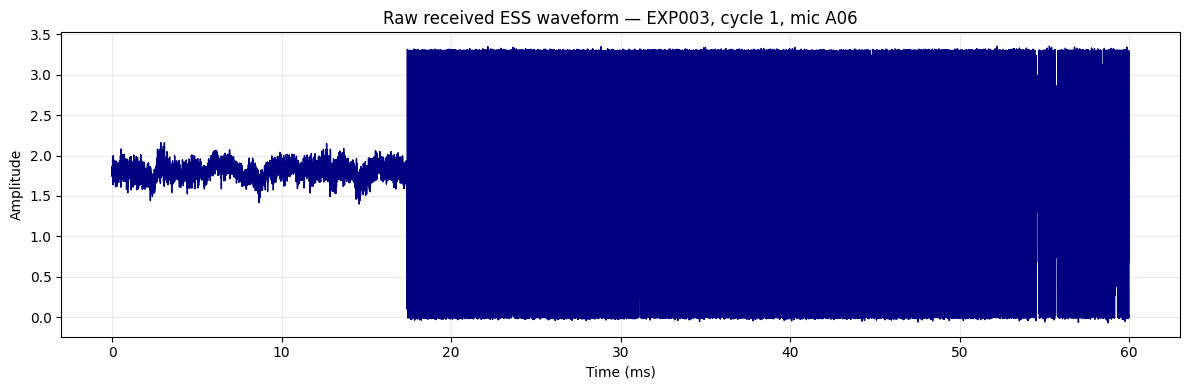

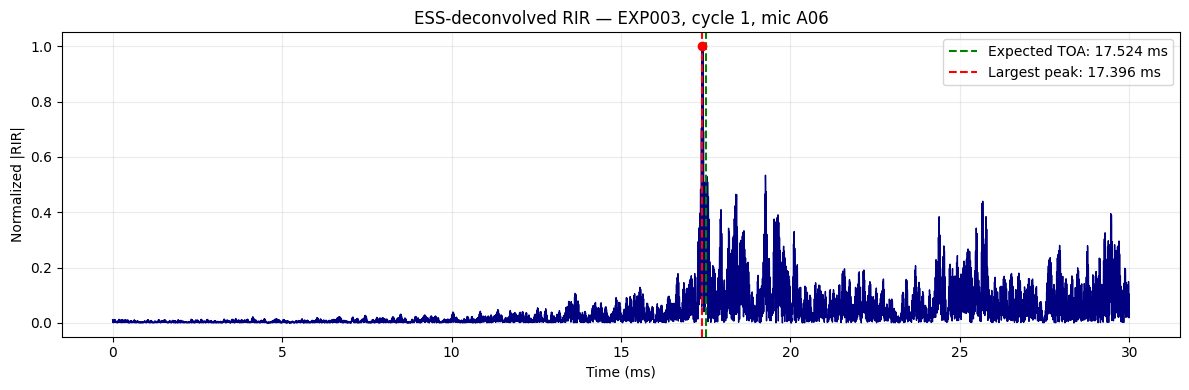

In [8]:
# Select one example to visualize.
example_exp_id = "EXP003"
example_cycle_id = 1
example_mic = "A06"   # change to "D10" or another label if desired

# Load one experiment and extract one cycle.
ds_exp = load_experiment_dataset(example_exp_id)
X_match, labels_match, mic_coords = get_cycle_waveforms_and_geometry(
    ds_exp, example_exp_id, example_cycle_id
)

# Find the row corresponding to the requested microphone.
if example_mic not in labels_match:
    raise ValueError(f"{example_mic} not found in valid microphones for {example_exp_id}, cycle {example_cycle_id}")
mic_idx = np.where(labels_match == example_mic)[0][0]
rx = np.asarray(X_match[mic_idx], dtype=float)

# Deconvolve the raw waveform into an RIR.
rir = ess_deconvolve_one(rx, chirp_excitation, CHIRP_CONFIG)
rir_abs_norm = np.abs(rir) / np.max(np.abs(rir))

# Estimate TOA using the largest RIR peak.
toa_est_sec, peak_idx = largest_peak_toa(rir, fs)
toa_est_ms = toa_est_sec * 1000

# Calculate expected geometric TOA for comparison.
tx_true = get_tx_position(example_exp_id, example_cycle_id)
mic_pos = np.array(mic_positions[example_mic], dtype=float)
distance_m = np.linalg.norm(tx_true - mic_pos)
toa_expected_ms = distance_m / c * 1000

print(f"Mic {example_mic} position: {mic_pos}")
print(f"TX true position: {tx_true}")
print(f"Distance: {distance_m:.4f} m")
print(f"Expected TOA: {toa_expected_ms:.4f} ms")
print(f"Estimated TOA: {toa_est_ms:.4f} ms")
print(f"Range-equivalent TOA error: {(toa_est_ms - toa_expected_ms) / 1000 * c:.4f} m")

# Plot raw waveform.
raw_time_ms = np.arange(len(rx)) / fs * 1000
plt.figure(figsize=(12, 4))
plt.plot(raw_time_ms, rx, linewidth=1.0, color="navy")
plt.title(f"Raw received ESS waveform — {example_exp_id}, cycle {example_cycle_id}, mic {example_mic}")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Plot deconvolved RIR with expected and estimated TOA markers.
rir_time_ms = np.arange(len(rir_abs_norm)) / fs * 1000
plt.figure(figsize=(12, 4))
plt.plot(rir_time_ms, rir_abs_norm, linewidth=1.0, color="navy")
plt.axvline(toa_expected_ms, color="green", linestyle="--", label=f"Expected TOA: {toa_expected_ms:.3f} ms")
plt.axvline(toa_est_ms, color="red", linestyle="--", label=f"Largest peak: {toa_est_ms:.3f} ms")
plt.scatter(toa_est_ms, rir_abs_norm[peak_idx], color="red", zorder=5)
plt.title(f"ESS-deconvolved RIR — {example_exp_id}, cycle {example_cycle_id}, mic {example_mic}")
plt.xlabel("Time (ms)")
plt.ylabel("Normalized |RIR|")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


## 6. Extract TOAs for all microphones in one cycle

This function applies ESS deconvolution to each valid microphone waveform and extracts a TOA from the largest RIR peak.


In [9]:
def estimate_toas_for_cycle(ds_exp: xr.Dataset, exp_id: str, cycle_id: int) -> pd.DataFrame:
    """Estimate largest-peak TOAs for all valid microphones in one cycle.

    Returns
    -------
    toa_df : pd.DataFrame
        One row per microphone, including mic position, TOA, expected TOA,
        and range-equivalent timing error when ground truth is available.
    """
    X_match, labels_match, mic_coords = get_cycle_waveforms_and_geometry(ds_exp, exp_id, cycle_id)
    tx_true = get_tx_position(exp_id, cycle_id)

    rows = []
    for label, rx, mic_pos in zip(labels_match, X_match, mic_coords):
        rir = ess_deconvolve_one(rx, chirp_excitation, CHIRP_CONFIG)
        toa_sec, peak_idx = largest_peak_toa(rir, fs)
        toa_ms = toa_sec * 1000

        distance = np.linalg.norm(tx_true - mic_pos)
        expected_toa_ms = distance / c * 1000
        error_ms = toa_ms - expected_toa_ms
        error_m = error_ms / 1000 * c

        rows.append({
            "experiment_id": exp_id,
            "cycle_id": int(cycle_id),
            "mic": label,
            "mic_x": mic_pos[0],
            "mic_y": mic_pos[1],
            "mic_z": mic_pos[2],
            "peak_sample": peak_idx,
            "toa_ms": toa_ms,
            "expected_toa_ms": expected_toa_ms,
            "range_equivalent_error_m": error_m,
            "abs_range_equivalent_error_m": abs(error_m),
        })

    return pd.DataFrame(rows)


# Example: TOAs for all microphones in EXP003/cycle 1.
toa_df = estimate_toas_for_cycle(ds_exp, "EXP003", 1)
print(toa_df.head())
print("Number of microphone TOAs:", len(toa_df))
print("Median absolute range-equivalent TOA error:", toa_df["abs_range_equivalent_error_m"].median(), "m")


  experiment_id  cycle_id  mic  mic_x  mic_y  mic_z  peak_sample  toa_ms  \
0        EXP003         1  A06  7.408  1.067  2.400         4349  17.396   
1        EXP003         1  A08  7.408  2.267  2.400         4175  16.700   
2        EXP003         1  A09  7.408  2.867  2.400         4418  17.672   
3        EXP003         1  A10  7.408  3.467  2.400         6257  25.028   
4        EXP003         1  A11  7.408  4.000  2.066         4388  17.552   

   expected_toa_ms  range_equivalent_error_m  abs_range_equivalent_error_m  
0        17.523572                 -0.043757                      0.043757  
1        16.811794                 -0.038345                      0.038345  
2        16.721145                  0.326143                      0.326143  
3        16.812997                  2.817746                      2.817746  
4        16.794812                  0.259715                      0.259715  
Number of microphone TOAs: 91
Median absolute range-equivalent TOA error: 0.15328

## 7. TOA localization with unknown emission time

If the transmitter emission time or processing delay is unknown, solve for it explicitly.

For microphone $i$:

$$
t_i = t_0 + \frac{\|x - p_i\|}{c}
$$

Unknowns:
- $x = [x, y, z]$: transmitter position,
- $t_0$: unknown emission/processing time offset.

The solver estimates all four unknowns: `[x, y, z, t0]`.


In [10]:
def toa_residual(params: np.ndarray, mic_coords: np.ndarray, toa_sec: np.ndarray, c_local: float = 343.0) -> np.ndarray:
    """Residual for TOA localization with unknown emission time.

    Parameters
    ----------
    params : np.ndarray
        [x, y, z, t0], where t0 is an unknown timing offset.
    mic_coords : np.ndarray
        Microphone coordinates, shape (num_mics, 3).
    toa_sec : np.ndarray
        Measured TOAs in seconds, shape (num_mics,).
    c_local : float
        Speed of sound in m/s.

    Returns
    -------
    residual : np.ndarray
        Measured TOA minus predicted TOA for each microphone.
    """
    source_pos = params[:3]
    t0 = params[3]
    distances = np.linalg.norm(mic_coords - source_pos, axis=1)
    toa_pred = t0 + distances / c_local
    return toa_sec - toa_pred


def solve_toa_unknown_t0(toa_df: pd.DataFrame, c_local: float = 343.0, f_scale: float = 0.001):
    """Solve TOA localization with unknown emission time using robust least squares.

    Robust loss is used because some microphones may select a reflected peak rather
    than the true direct-path peak.

    Parameters
    ----------
    toa_df : pd.DataFrame
        Output from estimate_toas_for_cycle().
    c_local : float
        Speed of sound in m/s.
    f_scale : float
        Robust loss scale in seconds. 0.001 s corresponds to about 34 cm.

    Returns
    -------
    res : scipy.optimize.OptimizeResult
        Least-squares result object. res.x[:3] is position; res.x[3] is t0.
    """
    mic_coords = toa_df[["mic_x", "mic_y", "mic_z"]].values.astype(float)
    toa_sec = toa_df["toa_ms"].values.astype(float) / 1000

    valid = np.isfinite(toa_sec) & np.all(np.isfinite(mic_coords), axis=1)
    mic_coords = mic_coords[valid]
    toa_sec = toa_sec[valid]

    # Initial position guess: centroid of the microphone array.
    x0_guess = np.mean(mic_coords, axis=0)

    # Initial t0 guess from t_i ≈ t0 + d_i/c.
    dist0 = np.linalg.norm(mic_coords - x0_guess, axis=1)
    t0_guess = np.min(toa_sec - dist0 / c_local)
    p0 = np.r_[x0_guess, t0_guess]

    res = least_squares(
        toa_residual,
        p0,
        args=(mic_coords, toa_sec, c_local),
        loss="soft_l1",      # robust to outlier TOAs
        f_scale=f_scale,
        max_nfev=5000,
    )
    return res


def localize_cycle(ds_exp: xr.Dataset, exp_id: str, cycle_id: int) -> dict:
    """Estimate TOAs, solve for TX position, and compute 2D/3D error for one cycle."""
    toa_df = estimate_toas_for_cycle(ds_exp, exp_id, cycle_id)
    res = solve_toa_unknown_t0(toa_df, c_local=c, f_scale=0.001)

    x_est = res.x[:3]
    t0_est = res.x[3]
    tx_true = get_tx_position(exp_id, cycle_id)

    error_2d_m = np.linalg.norm(x_est[:2] - tx_true[:2])
    error_3d_m = np.linalg.norm(x_est - tx_true)
    error_z_m = abs(x_est[2] - tx_true[2])

    mic_coords = toa_df[["mic_x", "mic_y", "mic_z"]].values.astype(float)
    toa_sec = toa_df["toa_ms"].values.astype(float) / 1000
    residuals_m = toa_residual(res.x, mic_coords, toa_sec, c) * c

    return {
        "experiment_id": exp_id,
        "cycle_id": int(cycle_id),
        "num_mics": len(toa_df),
        "x_est": x_est[0],
        "y_est": x_est[1],
        "z_est": x_est[2],
        "t0_est_s": t0_est,
        "x_true": tx_true[0],
        "y_true": tx_true[1],
        "z_true": tx_true[2],
        "error_2d_m": error_2d_m,
        "error_3d_m": error_3d_m,
        "error_z_m": error_z_m,
        "median_abs_residual_m": np.median(np.abs(residuals_m)),
        "mean_abs_residual_m": np.mean(np.abs(residuals_m)),
        "max_abs_residual_m": np.max(np.abs(residuals_m)),
        "solver_success": res.success,
        "solver_cost": res.cost,
    }


# Example localization for EXP003/cycle 1.
example_result = localize_cycle(ds_exp, "EXP003", 1)
example_result


{'experiment_id': 'EXP003',
 'cycle_id': 1,
 'num_mics': 91,
 'x_est': np.float64(1.8848719336924395),
 'y_est': np.float64(2.827489135673658),
 'z_est': np.float64(0.5642523404681378),
 't0_est_s': np.float64(0.0004091318762037634),
 'x_true': np.float64(1.9183037109375),
 'y_true': np.float64(2.865016845703125),
 'z_true': np.float64(0.7394267578125),
 'error_2d_m': np.float64(0.050259454332683626),
 'error_3d_m': np.float64(0.18224184273035626),
 'error_z_m': np.float64(0.17517441734436223),
 'median_abs_residual_m': np.float64(0.18896087537125114),
 'mean_abs_residual_m': np.float64(0.388121113789773),
 'max_abs_residual_m': np.float64(4.273411039408317),
 'solver_success': True,
 'solver_cost': np.float64(6.386278846306817e-05)}

## 8. Run localization for all cycles in selected experiments

This may take a while because each microphone waveform is deconvolved. Progress messages are printed so you can monitor runtime.


In [11]:
all_rows = []

for exp_id in EXPERIMENT_IDS:
    ds_exp = load_experiment_dataset(exp_id)
    cycle_ids = ds_exp["cycle_id"].values
    total_cycles = len(cycle_ids)

    print(f"\n--- {exp_id}: {total_cycles} cycles ---")
    start_time_exp = time.time()

    for i, cycle_id in enumerate(cycle_ids, start=1):
        cycle_start = time.time()
        try:
            row = localize_cycle(ds_exp, exp_id, int(cycle_id))
            all_rows.append(row)
        except Exception as exc:
            print(f"\nFailed {exp_id}, cycle {cycle_id}: {exc}")

        elapsed_cycle = time.time() - cycle_start
        elapsed_exp = time.time() - start_time_exp
        avg_time = elapsed_exp / i
        eta = avg_time * (total_cycles - i)

        print(
            f"{exp_id} | Cycle {i}/{total_cycles} | "
            f"{elapsed_cycle:.2f}s/cycle | ETA {eta:.1f}s",
            end="\r",
        )

    print(f"\nFinished {exp_id} in {time.time() - start_time_exp:.1f}s")

results_all_cycles_df = pd.DataFrame(all_rows)
print("\nTotal localized cases:", len(results_all_cycles_df))
results_all_cycles_df.head()



--- EXP003: 529 cycles ---
EXP003 | Cycle 529/529 | 0.25s/cycle | ETA 0.0sss
Finished EXP003 in 281.9s

--- EXP006: 238 cycles ---
EXP006 | Cycle 238/238 | 0.09s/cycle | ETA 0.0ss
Finished EXP006 in 40.7s

--- EXP007: 379 cycles ---
EXP007 | Cycle 378/379 | 0.09s/cycle | ETA 0.2ss
Failed EXP007, cycle 379: Expected 1 TX row for EXP007, cycle 379; found 0
EXP007 | Cycle 379/379 | 0.05s/cycle | ETA 0.0s
Finished EXP007 in 70.3s

--- EXP008: 201 cycles ---
EXP008 | Cycle 201/201 | 0.10s/cycle | ETA 0.0ss
Finished EXP008 in 36.1s

--- EXP010: 458 cycles ---
EXP010 | Cycle 458/458 | 0.37s/cycle | ETA 0.0sss
Finished EXP010 in 221.1s

--- EXP011: 291 cycles ---
EXP011 | Cycle 291/291 | 0.25s/cycle | ETA 0.0ss
Finished EXP011 in 56.9s

Total localized cases: 2095


,experiment_id,cycle_id,num_mics,x_est,y_est,z_est,t0_est_s,x_true,y_true,z_true,error_2d_m,error_3d_m,error_z_m,median_abs_residual_m,mean_abs_residual_m,max_abs_residual_m,solver_success,solver_cost
0,EXP003,1,91,1.884872,2.827489,0.564252,0.000409,1.918304,2.865017,0.739427,0.050259,0.182242,0.175174,0.188961,0.388121,4.273411,True,0.000064
1,EXP003,2,91,2.574473,2.230773,0.486556,0.000417,2.541446,2.253701,0.740059,0.040206,0.256672,0.253504,0.165100,0.516317,4.625115,True,0.000098
2,EXP003,3,91,2.634111,2.310769,0.559623,0.000634,2.535861,2.375249,0.740080,0.117519,0.215350,0.180457,0.186794,0.512377,4.641555,True,0.000093
3,EXP003,4,91,2.543537,2.459277,0.676261,0.000830,2.535490,2.495153,0.740458,0.036767,0.073981,0.064197,0.228615,0.569314,4.811783,True,0.000105
4,EXP003,5,91,2.507611,2.618365,0.560475,0.000497,2.535433,2.614717,0.740804,0.028061,0.182499,0.180329,0.197076,0.405044,3.578856,True,0.000066


## 9. Summarize 2D and 3D localization error

These summary statistics are useful for reporting overall performance and comparing experiments.


In [12]:
# Overall descriptive statistics.
overall_stats = results_all_cycles_df[["error_2d_m", "error_3d_m", "error_z_m"]].agg(
    ["mean", "median", "std"]
)

print("=== Overall error statistics ===")
print(overall_stats)

# Per-experiment descriptive statistics.
by_experiment_stats = (
    results_all_cycles_df
    .groupby("experiment_id")[["error_2d_m", "error_3d_m", "error_z_m"]]
    .agg(["mean", "median", "std"])
)

print("\n=== Error statistics by experiment ===")
print(by_experiment_stats)


=== Overall error statistics ===
        error_2d_m  error_3d_m  error_z_m
mean      0.091392    0.238377   0.205779
median    0.081393    0.235875   0.208100
std       0.062353    0.089861   0.101568

=== Error statistics by experiment ===
              error_2d_m                     error_3d_m                      \
                    mean    median       std       mean    median       std   
experiment_id                                                                 
EXP003          0.082215  0.076042  0.046804   0.213067  0.206149  0.079533   
EXP006          0.068052  0.064290  0.040801   0.261081  0.256145  0.068033   
EXP007          0.075086  0.072885  0.033578   0.275753  0.273414  0.080619   
EXP008          0.094587  0.079541  0.065562   0.210459  0.195360  0.078327   
EXP010          0.093312  0.090573  0.045936   0.241640  0.241386  0.091194   
EXP011          0.143119  0.112128  0.106415   0.231419  0.212293  0.114909   

              error_z_m                      
 

## 10. Plot error distributions

Histograms and boxplots are quick ways to check whether the mean error is dominated by a few outliers.


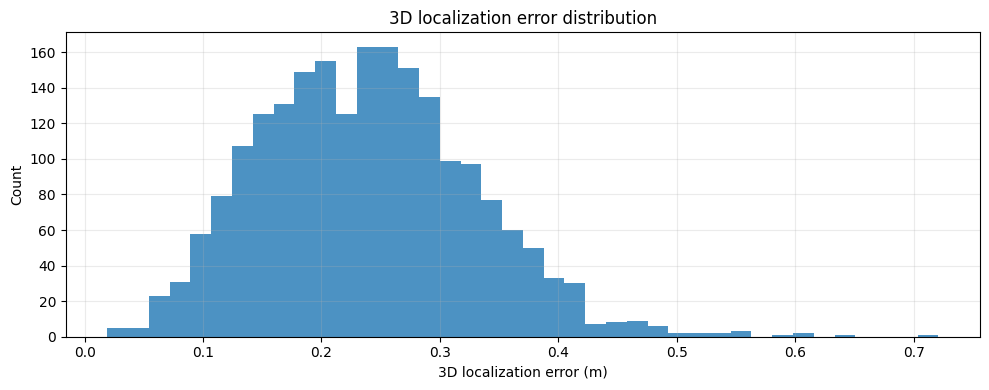

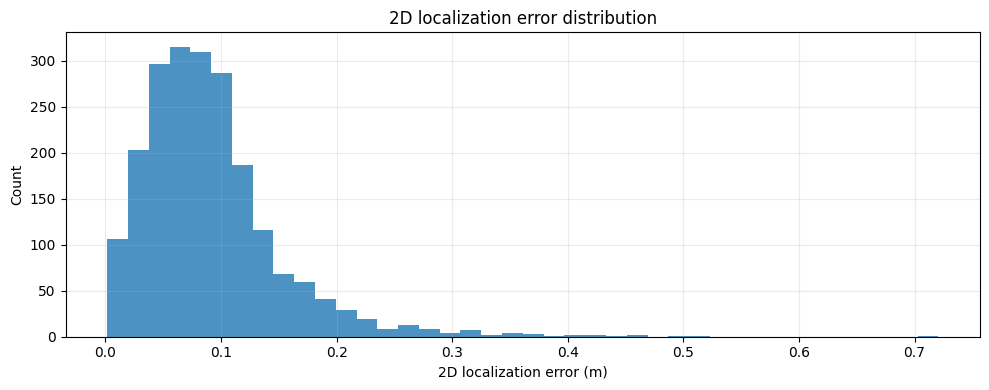

<Figure size 1000x450 with 0 Axes>

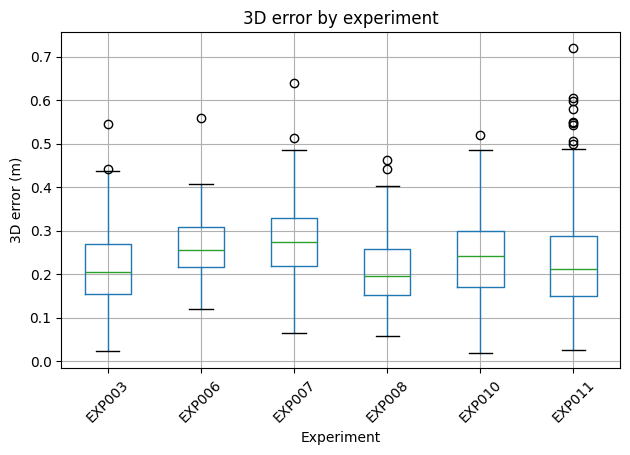

In [13]:
plt.figure(figsize=(10, 4))
plt.hist(results_all_cycles_df["error_3d_m"], bins=40, alpha=0.8)
plt.xlabel("3D localization error (m)")
plt.ylabel("Count")
plt.title("3D localization error distribution")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(results_all_cycles_df["error_2d_m"], bins=40, alpha=0.8)
plt.xlabel("2D localization error (m)")
plt.ylabel("Count")
plt.title("2D localization error distribution")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
results_all_cycles_df.boxplot(column="error_3d_m", by="experiment_id", rot=45)
plt.suptitle("")
plt.title("3D error by experiment")
plt.xlabel("Experiment")
plt.ylabel("3D error (m)")
plt.tight_layout()
plt.show()


## 11. Notes and possible improvements

This notebook intentionally keeps the method simple. To improve performance, consider:

1. **More robust TOA peak selection**
   - Largest peak can select a strong reflection.
   - A first-arrival detector or geometry-aided peak picker may reduce multipath bias.

2. **Speed of sound calibration**
   - The speed of sound depends on temperature and humidity.
   - A small error in $c$ can bias TOA-based localization.

3. **Peak-quality weighting**
   - Instead of dropping microphones, weight each TOA by peak prominence or signal-to-noise ratio.

4. **Iterative geometry-aided TOA refinement**
   - First solve with largest peaks.
   - Predict each mic's TOA from the estimated position.
   - Re-pick peaks only near the predicted arrival window.
   - Re-solve localization.

5. **Vectorization / FFT convolution**
   - This implementation uses straightforward time-domain convolution.
   - For large-scale processing, FFT-based convolution may be faster.
